# In this file, we test the trained unet model on the 2p_5p NFI Dataset. Then we compare the metrics of the model compared to human specialists.

In [1]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
from DNAnet.data.data_models.hid_dataset import HIDDataset
from DNAnet.evaluation import *
from DNAnet.evaluation.segmentation.allele_metrics import *

from DNAnet.evaluation.visualizations import plot_profile
from config_io import load_model

/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
images = HIDDataset(
  root="resources/data/2p_5p_Dataset_NFI/Raw data .HID files",
  panel="resources/data/SGPanel_PPF6C_SPOOR.xml",
  annotations_path="resources/data/2p_5p_Dataset_NFI/.txt bestanden 2024 naam",
  hid_to_annotations_path="resources/data/2p_5p_Dataset_NFI/2p_5p_hid_to_annotation.csv",
  limit=30,
  ground_truth_as_annotations=True
)

unet_model = load_model("config/models/unet.yaml")
unet_model.load("resources/model/current_best_unet/")

2025-08-19 17:03:09 INFO     Loading data from file
2025-08-19 17:03:09 INFO     Walking directory to retrieve all hid files...
Processing folders: 100%|██████████| 21/21 [00:00<00:00, 2554.76it/s]
2025-08-19 17:03:09 INFO     Found 350 HIDs
2025-08-19 17:03:09 INFO     Found 0 HIDs without ladder
2025-08-19 17:03:09 INFO     Removed 0 HIDs without annotation
2025-08-19 17:03:09 INFO     Limiting dataset to 30
Loading data from resources/data/2p_5p_Dataset_NFI/Raw data .HID files:   0%|          | 0/30 [00:00<?, ?it/s]2025-08-19 17:03:09 WARNING  Could not load true alleles for resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/ladder_G03_21.hid: Cannot load donor alleles for non-RD sample. Found file name ladder_G03_21
Could not load true alleles for resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/ladder_G03_21.hid: Cannot load donor alleles for non-RD sample. Found file name ladder_G0

In [4]:
predictions = unet_model.predict_batch(images)

2025-08-19 17:07:18 INFO     Calling alleles from predicted segmentation...


In [5]:
# Compute per-file metrics and store results with file names
per_file_metrics = []
for img, pred in zip(images, predictions):
    fname = img.path
    pixel_f1 = pixel_f1_score([img], [pred])
    pixel_prec = pixel_precision([img], [pred])
    pixel_rec = pixel_recall([img], [pred])
    allele_f1 = allele_f1_score([img], [pred])
    allele_prec = allele_precision([img], [pred])
    allele_rec = allele_recall([img], [pred])
    per_file_metrics.append({
        'filename': fname,
        'pixel_f1': pixel_f1,
        'pixel_precision': pixel_prec,
        'pixel_recall': pixel_rec,
        'allele_f1': allele_f1,
        'allele_precision': allele_prec,
        'allele_recall': allele_rec,
        'image': img,
        'prediction': pred
    })

In [6]:
# Sort and display worst files for each metric
def print_worst(metric_name, top_n=5):
    sorted_metrics = sorted(per_file_metrics, key=lambda x: x[metric_name])
    print(f'Worst {top_n} files by {metric_name}:')
    for i in range(top_n):
        m = sorted_metrics[i]
        print(f"{i+1}. {m['filename']} - {metric_name}: {m[metric_name]:.4f}")
    print()
    return [m['filename'] for m in sorted_metrics[:top_n]]
print_worst('pixel_f1')
print_worst('pixel_precision')
print_worst('pixel_recall')
print_worst('allele_f1')
print_worst('allele_precision')
print_worst('allele_recall')

Worst 5 files by pixel_f1:
1. resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/6B2_E02_14.hid - pixel_f1: 0.0000
2. resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj3 2017-05-16-15-20-54-099/6E2_A08_02.hid - pixel_f1: 0.0000
3. resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/6A2_A01_01.hid - pixel_f1: 0.0025
4. resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/6A2_A02_02.hid - pixel_f1: 0.0025
5. resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/6A2_E01_13.hid - pixel_f1: 0.0025

Worst 5 files by pixel_precision:
1. resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/6B2_E02_14.hid - pixel_precision: 0.0000
2. resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj3 2017-05-16-15-20-54-099/6E2_A0

[PosixPath('resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/6B2_E02_14.hid'),
 PosixPath('resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/6A2_A02_02.hid'),
 PosixPath('resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj3 2017-05-16-15-20-54-099/6D2_A07_01.hid'),
 PosixPath('resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj3 2017-05-16-15-20-54-099/6E2_A08_02.hid'),
 PosixPath('resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/6B2_A03_03.hid')]

In [7]:
# Visualize the worst file for a metric (template)
from DNAnet.evaluation.visualizations import plot_profile

worst_pixel_f1_file = print_worst('pixel_f1', top_n=3)[0]
worst_file = next(m for m in per_file_metrics if m['filename'] == worst_pixel_f1_file)
img = worst_file['image']
pred = worst_file['prediction']

# # TODO: Add your visualization code here, e.g.:
# plot_profile(hid_images=[img], predictions=[pred])
# # plot_profile_markers(hid_images=[image])

Worst 3 files by pixel_f1:
1. resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/6B2_E02_14.hid - pixel_f1: 0.0000
2. resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj3 2017-05-16-15-20-54-099/6E2_A08_02.hid - pixel_f1: 0.0000
3. resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/6A2_A01_01.hid - pixel_f1: 0.0025



In [8]:
# Compute overall hardest files ranking and keep the hidimage object for each file

def get_hardest_files(per_file_metrics, metrics, top_n=5):
    score_dict = {}
    file_data = {}
    for metric in metrics:
        sorted_metrics = sorted(per_file_metrics, key=lambda x: x[metric])
        for rank in range(top_n):
            entry = sorted_metrics[rank]
            fname = entry['filename']
            score = top_n - rank
            score_dict[fname] = score_dict.get(fname, 0) + score
            # Store the hidimage and prediction for each file (last occurrence will be kept)
            file_data[fname] = {'image': entry['image'], 'prediction': entry['prediction']}
    # Sort by score descending
    hardest = sorted(score_dict.items(), key=lambda x: -x[1])
    print(f"Overall hardest files (score = sum of (top_n - rank) for each appearance):")
    for i, (fname, score) in enumerate(hardest):
        print(f"{i+1}. {fname} - score: {score}")
    # Return list of dicts with filename, score, image, prediction
    return [{'filename': fname, 'score': score, 'image': file_data[fname]['image'], 'prediction': file_data[fname]['prediction']} for fname, score in hardest]

metrics = ['pixel_f1', 'pixel_precision', 'pixel_recall', 'allele_f1', 'allele_precision', 'allele_recall']
hardest_files = get_hardest_files(per_file_metrics, metrics, top_n=5)

Overall hardest files (score = sum of (top_n - rank) for each appearance):
1. resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/6B2_E02_14.hid - score: 28
2. resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/6A2_A02_02.hid - score: 19
3. resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj3 2017-05-16-15-20-54-099/6E2_A08_02.hid - score: 18
4. resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj3 2017-05-16-15-20-54-099/6D2_A07_01.hid - score: 9
5. resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/6A2_A01_01.hid - score: 8
6. resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/6A2_E01_13.hid - score: 7
7. resources/data/2p_5p_Dataset_NFI/Raw data .HID files/Mixture dataset 6/Inj1 2017-05-16-15-20-54-079/6B2_A03_03.hid - score: 1


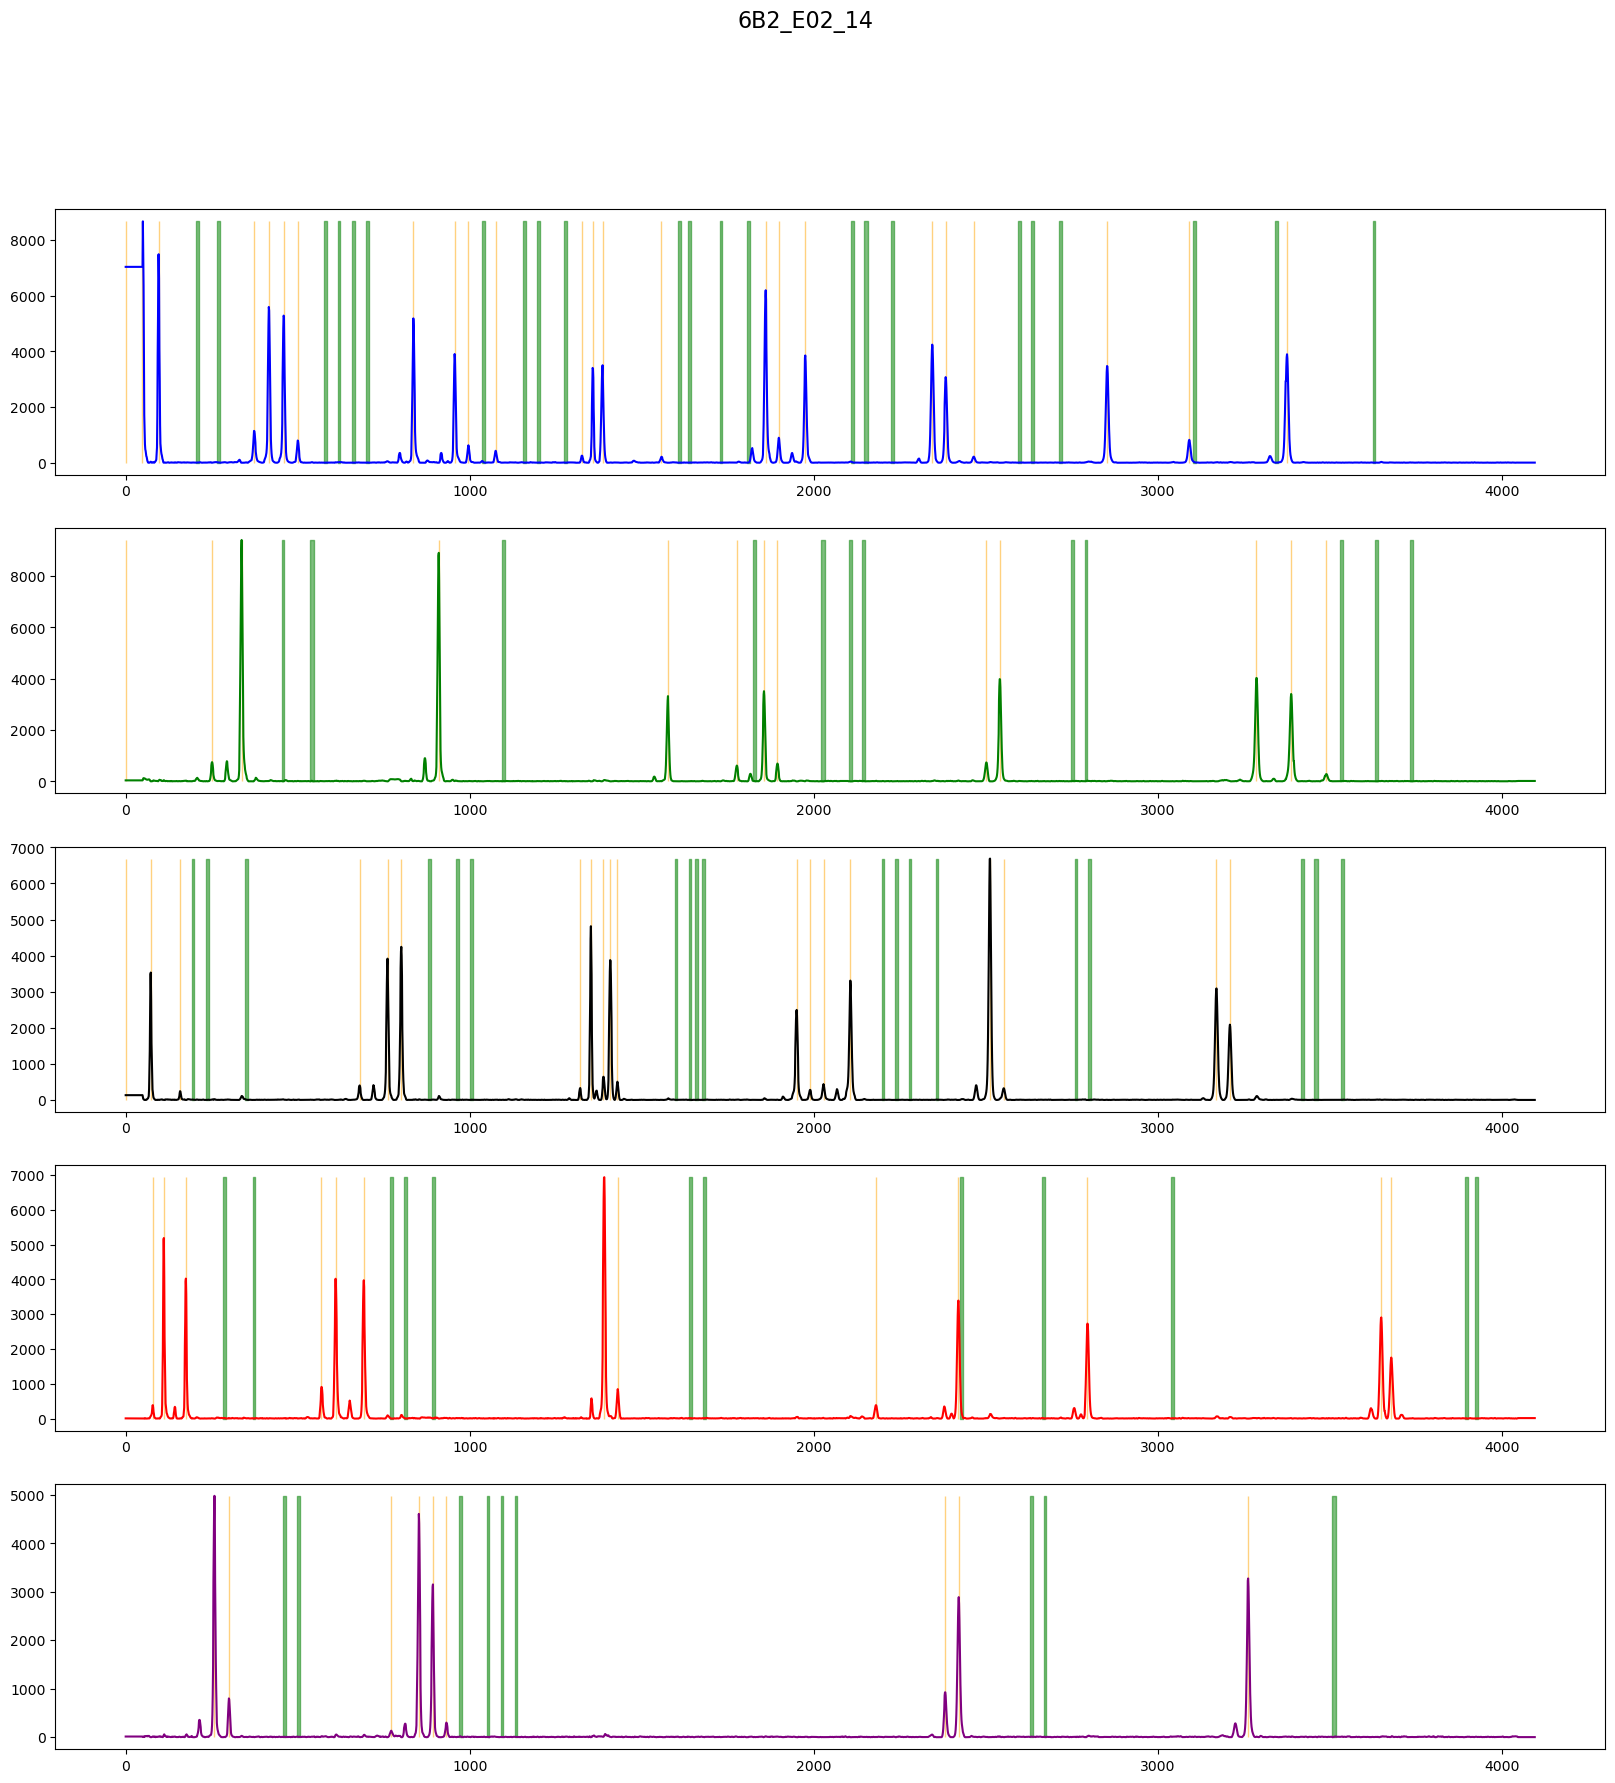

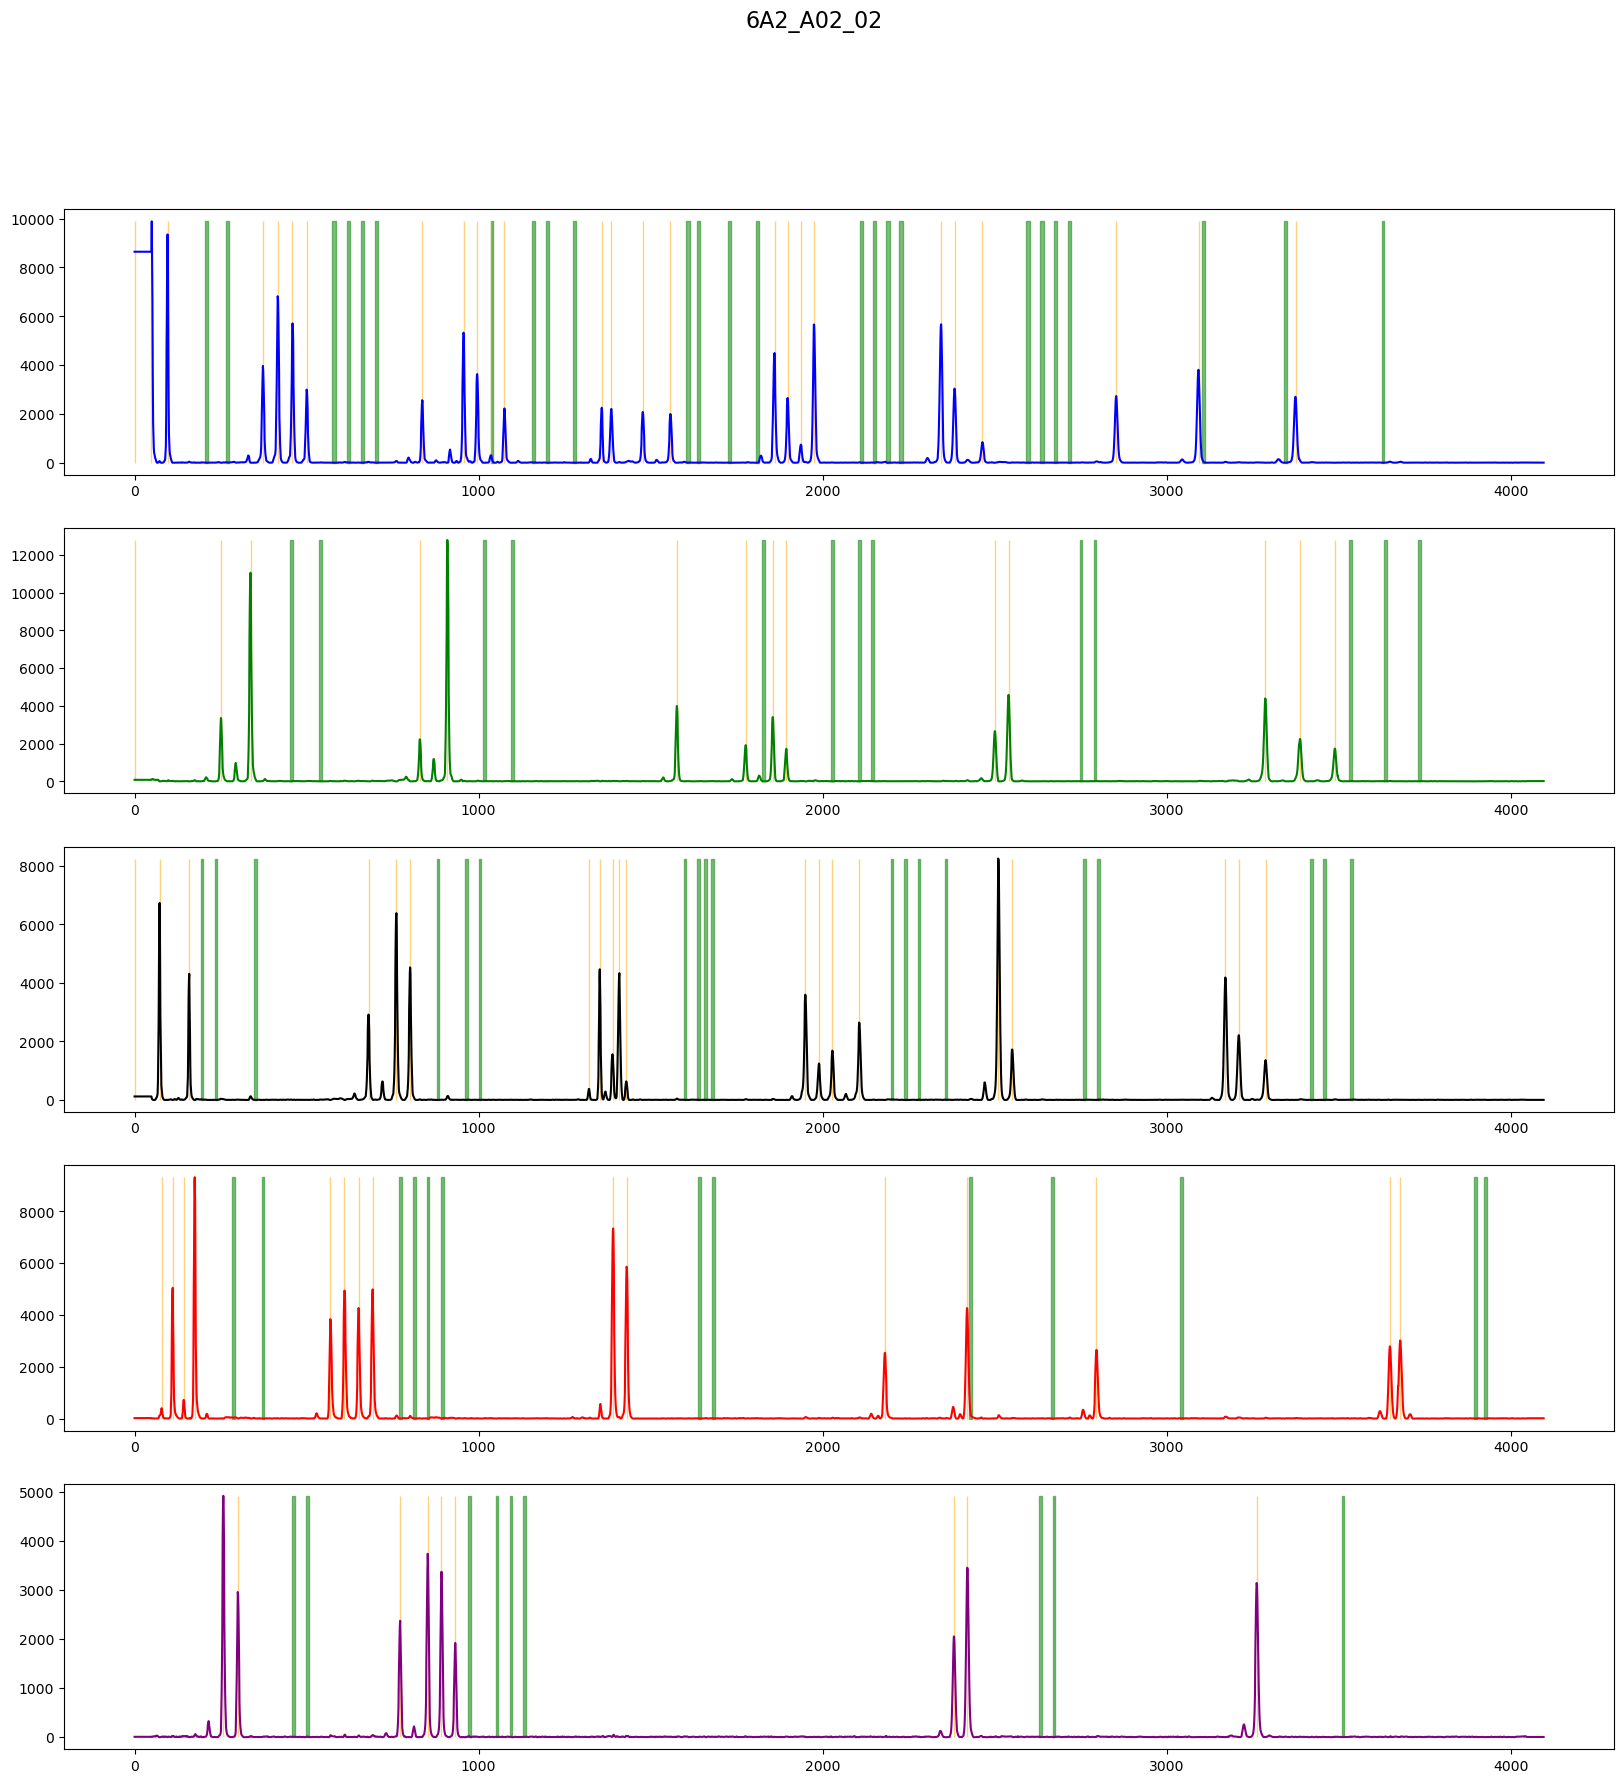

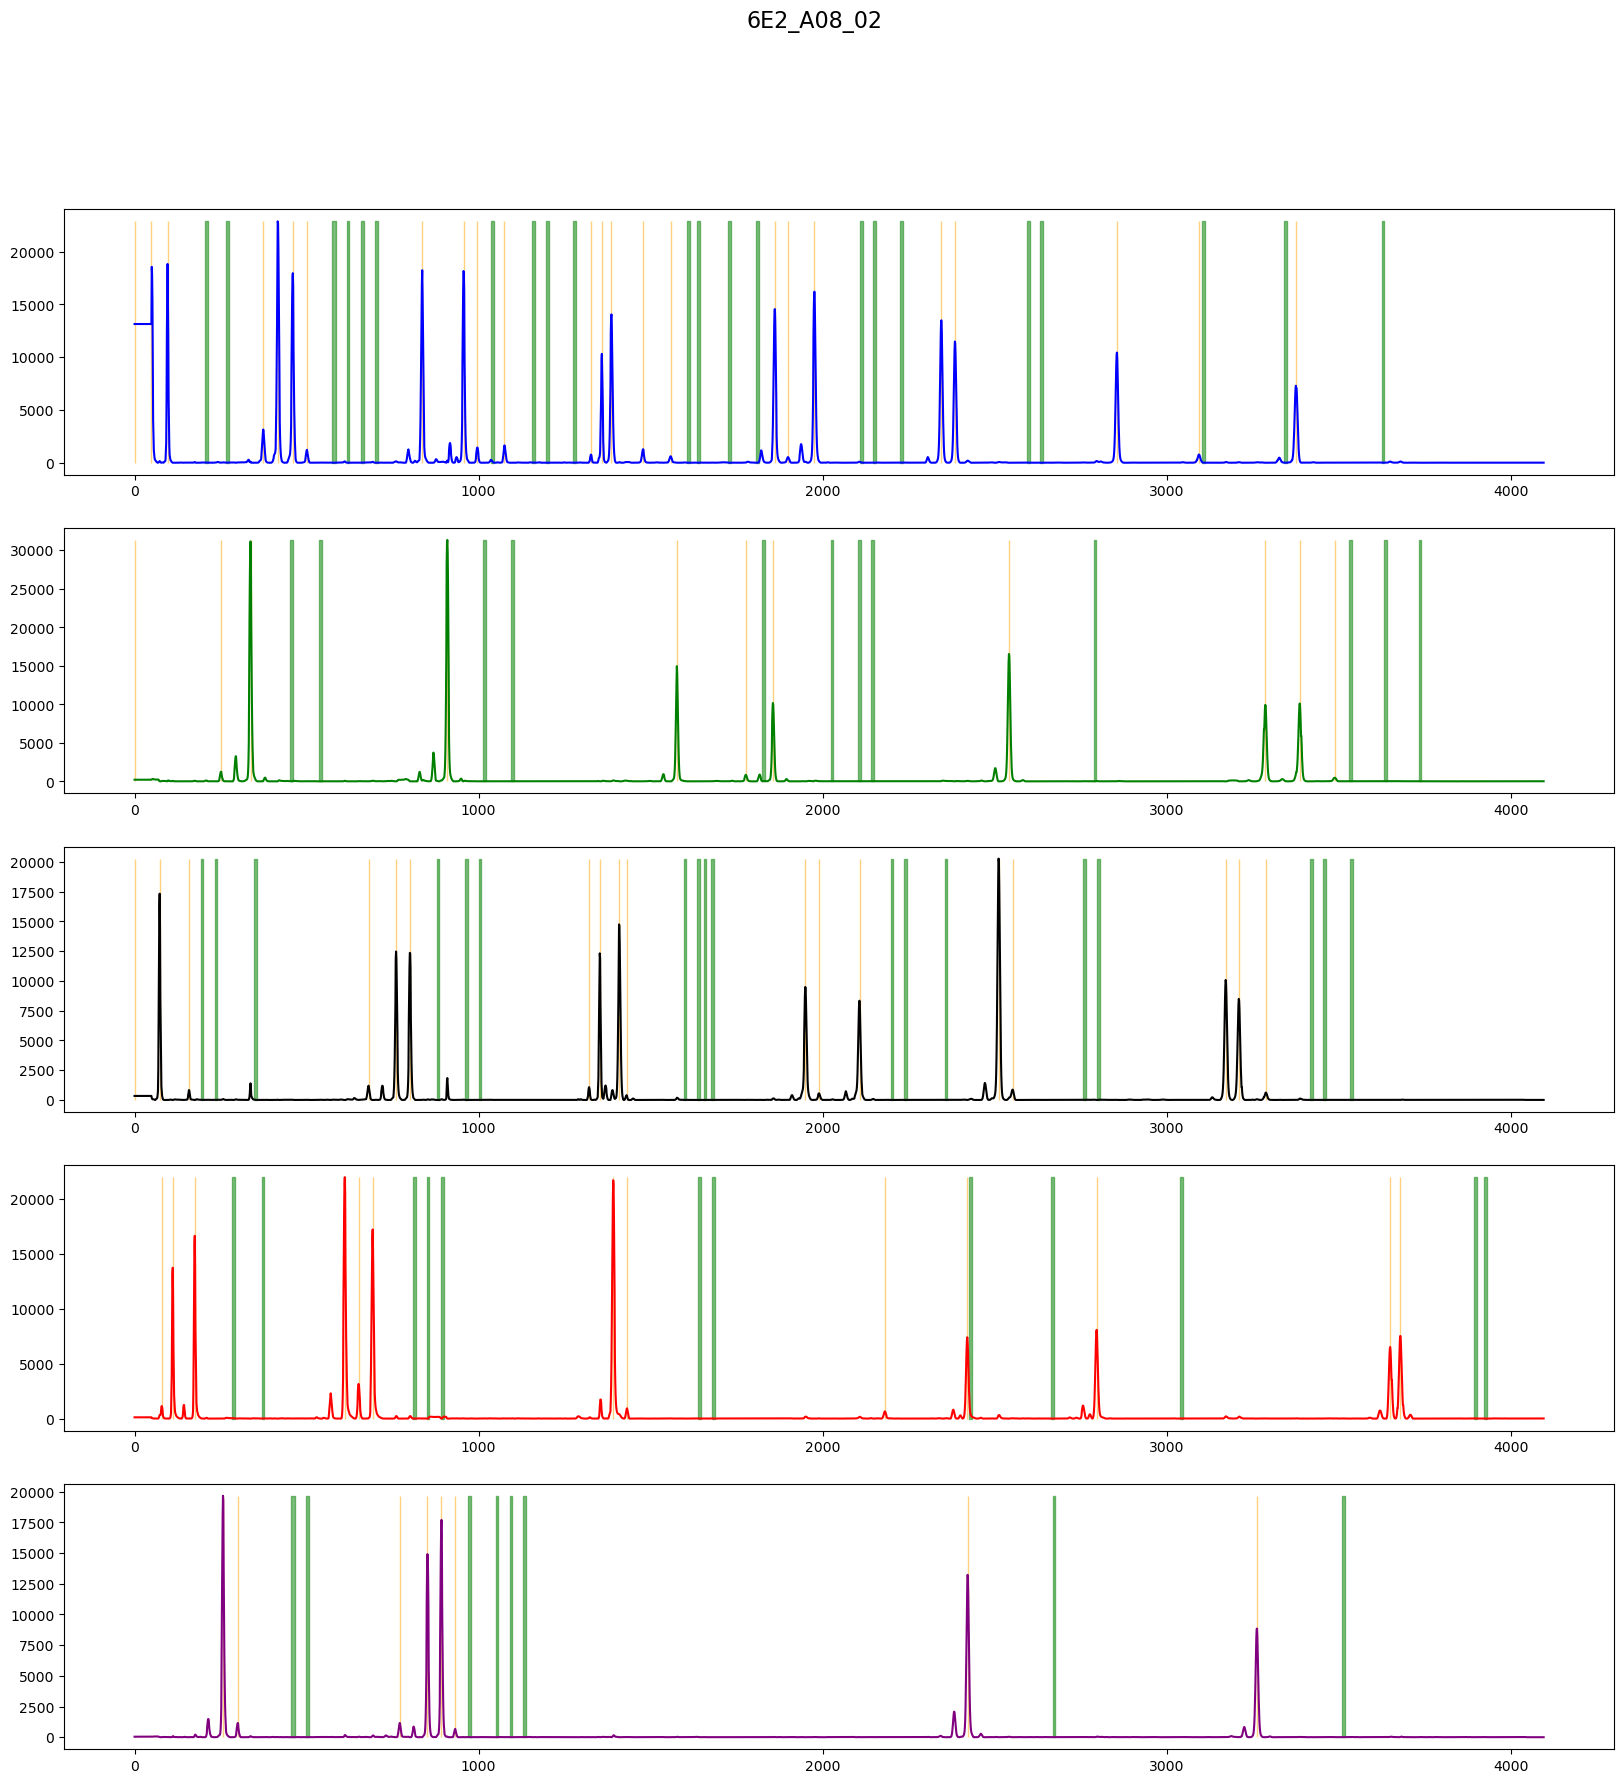

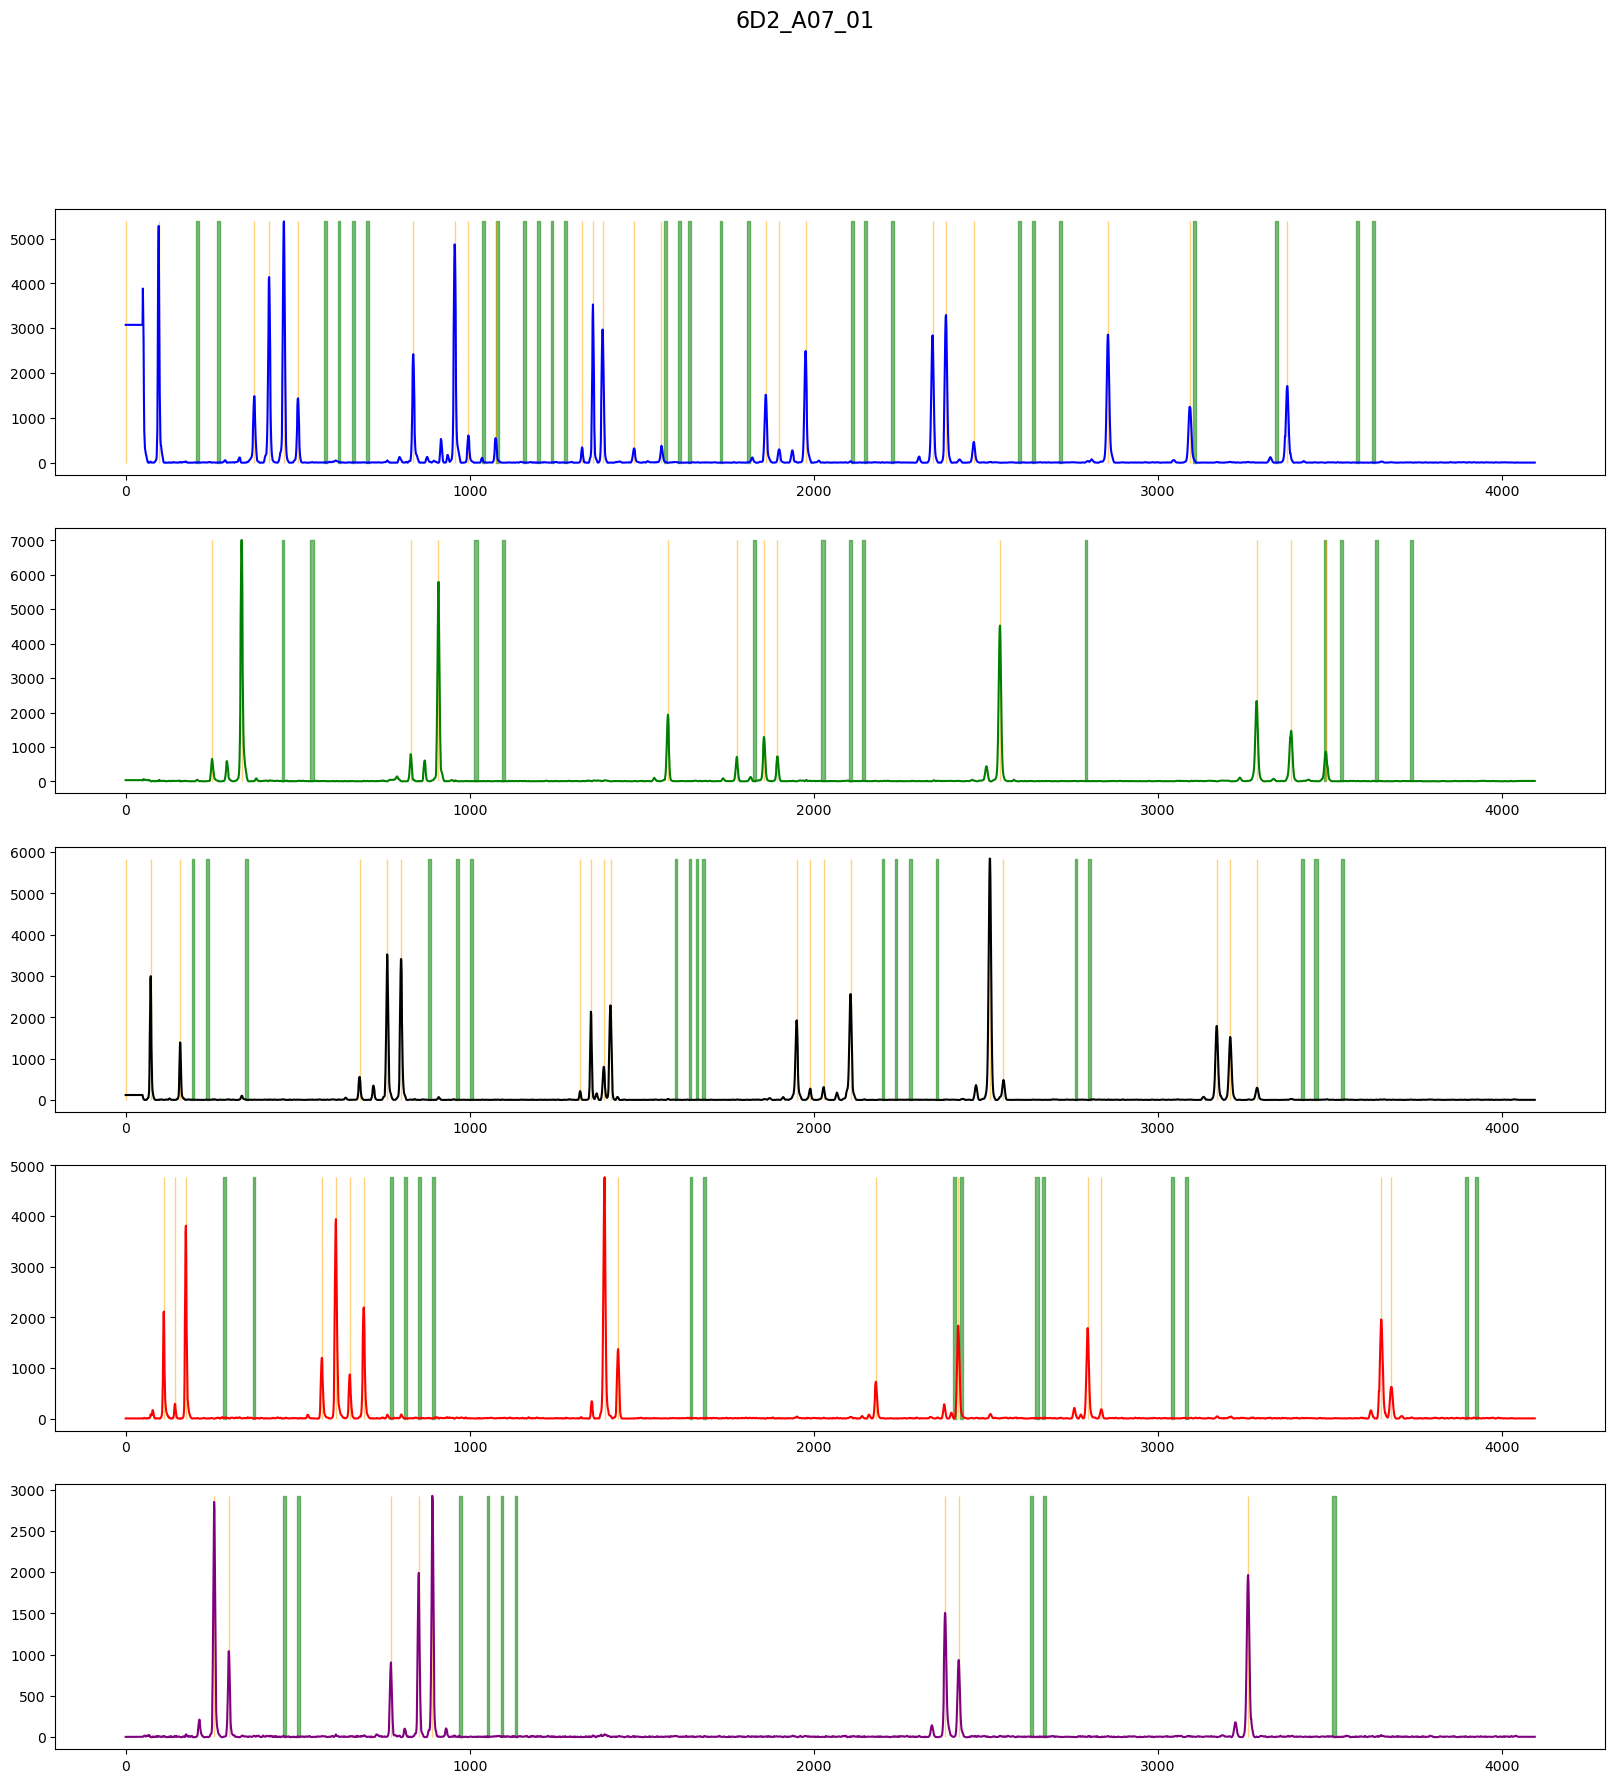

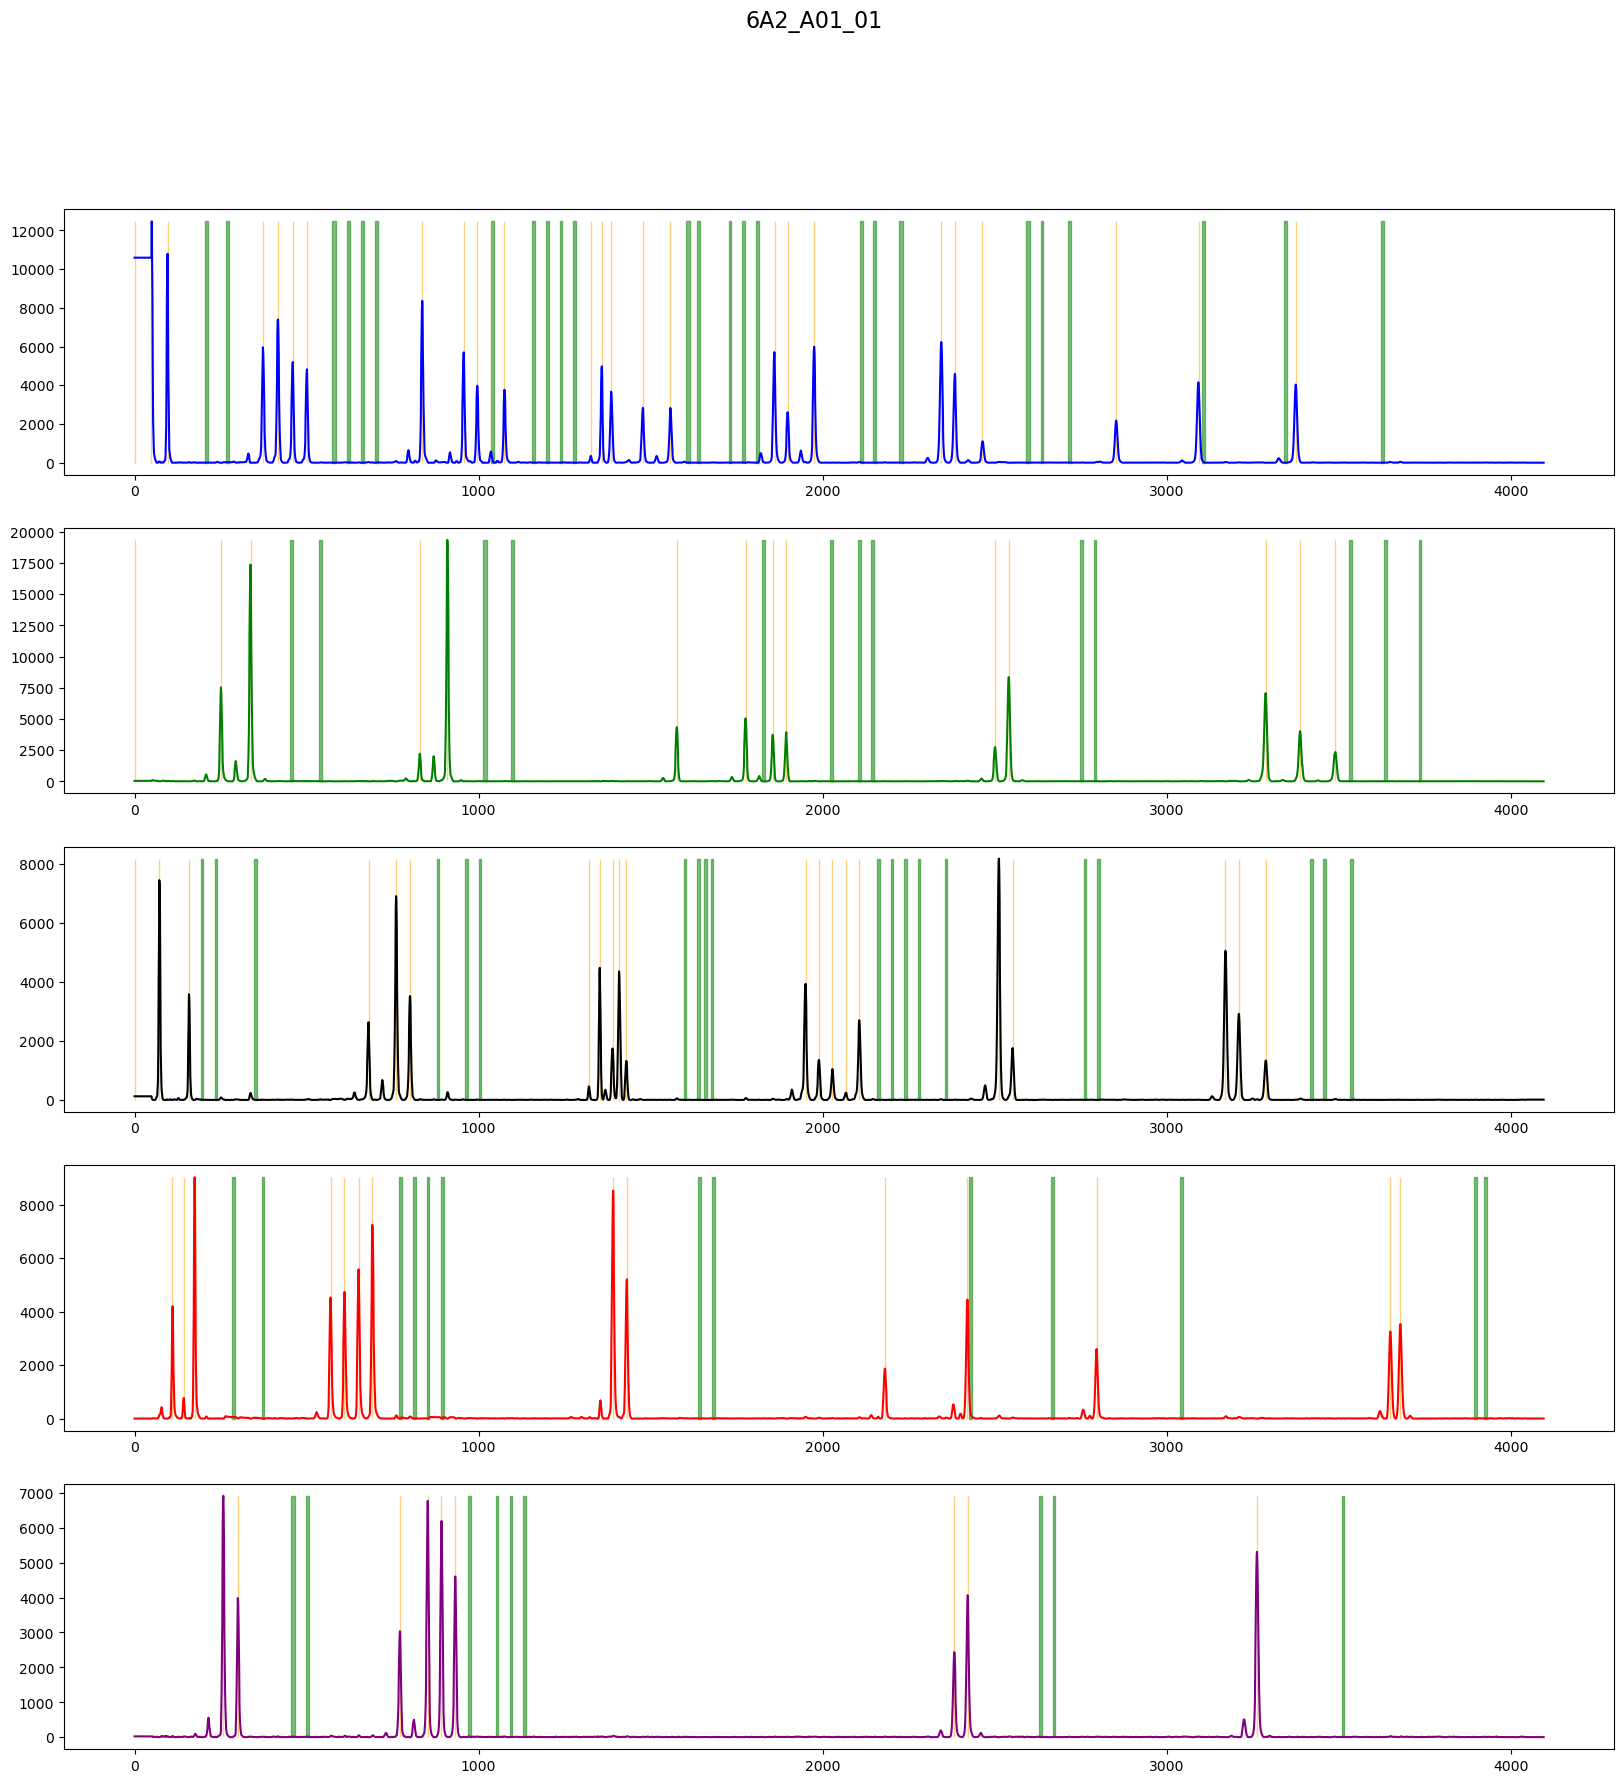

In [9]:
for file in hardest_files[:5]:
    plot_profile(hid_images=[file['image']], predictions=[file['prediction']])# plot_profile_markers(hid_images=[image])